In [3]:
!pip install mlflow -q
!pip install -q pyngrok
!npm install -g localtunnel
# REMOVE: !pip install numpy==1.26.4 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import ssl
from tqdm import tqdm
import pandas as pd
import mlflow
import mlflow.pytorch

from google.colab import drive

# Explicitly unmount drive to ensure a clean mount point
# This helps if previous mounts left files behind, even with force_remount=True
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except ValueError:
        pass # Drive might not be mounted, ignore error
    except Exception as e:
        print(f"Error during flush_and_unmount: {e}")

    # Check if the mount point is still a directory and not empty, then clean it
    if os.path.isdir('/content/drive') and len(os.listdir('/content/drive')) > 0:
        print("Mount point /content/drive is not empty. Cleaning up...")
        # Use a more robust way to remove contents if not empty
        import shutil
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            if os.path.isfile(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)


drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}\n")


Using device: cuda



In [ ]:
mlflow.set_experiment("FairVision_Age_Classification")


2026/05/14 16:37:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/14 16:37:51 INFO mlflow.store.db.utils: Updating database tables
2026/05/14 16:37:52 INFO mlflow.tracking.fluent: Experiment with name 'FairVision_Age_Classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='/kaggle/working/mlruns/1', creation_time=1778776672827, experiment_id='1', last_update_time=1778776672827, lifecycle_stage='active', name='FairVision_Age_Classification', tags={}, trace_location=None, workspace='default'>

In [20]:
batch_size = 32 # Reduced from 128 to avoid Colab OOM errors
learning_rate = 4e-6        # Lower learning rate for stability
weight_decay = 0.01        # Higher weight decay to force generalization
epochs = 20
validation_size = 5000
checkpoint_path = "best_fairface_model.pth"

In [25]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # 1. Image Augmentations (Must come BEFORE ToTensor)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),

    # 2. Convert to Tensor (Only call this ONCE)
    transforms.ToTensor(),

    # 3. Tensor Augmentations (Must come AFTER ToTensor)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

In [21]:

print("Loading FairFace dataset...")
dataset = load_dataset("HuggingFaceM4/FairFace", "0.25")
train_ds = dataset["train"]
test_ds = dataset["validation"]

Loading FairFace dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

0.25/train-00000-of-00002-d405faba4f4b9b(…):   0%|          | 0.00/250M [00:00<?, ?B/s]

0.25/train-00001-of-00002-dd3cb681647274(…):   0%|          | 0.00/250M [00:00<?, ?B/s]

0.25/validation-00000-of-00001-951dbd63c(…):   0%|          | 0.00/63.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/86744 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10954 [00:00<?, ? examples/s]

In [26]:
class FairFaceTorchDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image'].convert("RGB")
        label = item['age']
        race = item['race']
        gender = item['gender']

        if self.transform:
            image = self.transform(image)

        return image, label, race, gender


In [27]:
full_train_data = FairFaceTorchDataset(train_ds, transform=transform)
full_test_data = FairFaceTorchDataset(test_ds, transform=transform)

In [29]:
num_train = len(full_train_data)
indices = torch.randperm(num_train, generator=torch.Generator().manual_seed(42)).tolist()

val_indices = indices[:validation_size]
train_indices = indices[validation_size:]


In [30]:

train_dataset = Subset(full_train_data, train_indices)
val_dataset = Subset(full_train_data, val_indices)

In [31]:

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(full_test_data, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(full_test_data)}\n")


Training samples: 81744
Validation samples: 5000
Test samples: 10954



In [32]:
import torchvision.models as models

class FairVisionResNet(nn.Module):
    def __init__(self, num_classes=9):
        super(FairVisionResNet, self).__init__()
        # Load pre-trained ResNet50 - this gives you 50 layers of pre-learned features
        self.backbone = models.resnet50(weights='IMAGENET1K_V1')

        # Replace the final layer to match your 9 age classes
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.6), # Increased dropout to stop the overfitting you saw
            nn.Linear(num_ftrs, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Initialize the new model
model = FairVisionResNet(num_classes=9).to(device)

In [33]:
# Criterion remains the same (Label Smoothing is great for Age classification)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer: Using AdamW with your weight_decay is better for ResNet
optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

# Scheduler: Keep the OneCycleLR as it works perfectly with ResNet
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,             # The peak of the learning rate curve
    steps_per_epoch=len(train_loader),
    epochs=epochs
)

In [34]:
# Define path
save_dir = "/kaggle/working/fairvision"
checkpoint_path = os.path.join(save_dir, "checkpoint.pt")

# Only try to load if the file exists
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    best_val_accuracy = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1
else:
    print("No checkpoint found. Starting from scratch.")
    start_epoch = 0
    best_val_accuracy = 0.0

No checkpoint found. Starting from scratch.


In [35]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
best_val_accuracy = 0.0

In [39]:
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels, _, _ in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
    return running_loss / len(loader.dataset), 100 * correct / total



In [ ]:
import os
import torch
from tqdm import tqdm

# 1. SETUP KAGGLE DIRECTORY
save_dir = "/content/drive/MyDrive/kaggle/working/fairvision"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = os.path.join(save_dir, "checkpoint.pt")

# Ensure accuracy lists are initialized if not resuming
if 'train_losses' not in locals():
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

with mlflow.start_run(run_name="FairVision_ResNet50_Final"):

    # Log Hyperparameters
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("weight_decay", weight_decay)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("architecture", "ResNet50_TransferLearning")

    # 2. RESUME LOGIC
    if os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        best_val_accuracy = checkpoint["best_val_acc"]
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resumed from epoch {start_epoch}")
    else:
        start_epoch = 0
        best_val_accuracy = 0.0

    print("Starting training...")
    len_train = len(train_dataset)

    for epoch in range(start_epoch, epochs):
        model.train()
        running_train_loss, train_correct, train_total = 0.0, 0, 0

        # PROGRESS BAR
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, labels, _, _ in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # --- CRITICAL FIX 1: Optimizer Step ---
            optimizer.step()

            # --- CRITICAL FIX 2: OneCycleLR Step ---
            # OneCycleLR MUST step after every batch, not every epoch
            scheduler.step()

            # Stats
            running_train_loss += loss.item() * images.size(0)
            train_total += labels.size(0)
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()

            # Update progress bar info
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        # Training metrics
        epoch_train_loss = running_train_loss / len_train
        epoch_train_accuracy = 100 * train_correct / train_total

        # Validation
        epoch_val_loss, epoch_val_accuracy = evaluate(model, val_loader)

        # Log to MLflow
        mlflow.log_metric("train_loss", epoch_train_loss, step=epoch)
        mlflow.log_metric("train_acc", epoch_train_accuracy, step=epoch)
        mlflow.log_metric("val_loss", epoch_val_loss, step=epoch)
        mlflow.log_metric("val_acc", epoch_val_accuracy, step=epoch)

        # Store for plots
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        print(
            f"\nEpoch [{epoch+1}/{epochs}] Summary: "
            f"Train Acc: {epoch_train_accuracy:.2f}% | "
            f"Val Acc: {epoch_val_accuracy:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f}"
        )

        # 3. SAVE LOGIC (Save Best Model)
        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy

            # Log model to MLflow
            mlflow.pytorch.log_model(model, name="model_checkpoints")

            # Save local checkpoint
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_accuracy,
            }, checkpoint_path)

            print(f" New Best Model! Saved to {checkpoint_path}")

    print("\n Training Complete. All metrics logged to MLflow.")

Starting training...


Epoch 1/20: 100%|██████████| 2555/2555 [24:20<00:00,  1.75it/s, loss=1.5191]
2026/05/14 17:03:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Epoch [1/20] Summary: Train Acc: 35.49% | Val Acc: 46.16% | Val Loss: 1.5031


2026/05/14 17:03:14 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/14 17:03:29 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


 New Best Model! Saved to /kaggle/working/fairvision/checkpoint.pt


...


Epoch [18/20] Summary: Train Acc: 69.85% | Val Acc: 58.28% | Val Loss: 1.3133


Epoch 19/20: 100%|██████████| 2555/2555 [24:40<00:00,  1.73it/s, loss=1.0032]



Epoch [19/20] Summary: Train Acc: 70.67% | Val Acc: 58.60% | Val Loss: 1.2996


Epoch 20/20: 100%|██████████| 2555/2555 [24:41<00:00,  1.73it/s, loss=1.2553]



Epoch [20/20] Summary: Train Acc: 70.86% | Val Acc: 58.62% | Val Loss: 1.3030

 Training Complete. All metrics logged to MLflow.


In [43]:
def audit_model(model, loader):
    model.eval()
    results = []

    # Mapping dictionaries based on FairFace dataset standards
    race_map = {
        0: 'White', 1: 'Black', 2: 'Latino_Hispanic', 3: 'East Asian',
        4: 'Southeast Asian', 5: 'Indian', 6: 'Middle Eastern'
    }
    gender_map = {0: 'Male', 1: 'Female'}

    print("Starting Bias Audit...")
    with torch.no_grad():
        for images, labels, races, genders in tqdm(loader):
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            for i in range(len(preds)):
                results.append({
                    'pred': preds[i].item(),
                    'label': labels[i].item(),
                    'race': race_map.get(races[i].item(), "Unknown"),
                    'gender': gender_map.get(genders[i].item(), "Unknown")
                })

    df = pd.DataFrame(results)
    df['correct'] = df['pred'] == df['label']
    # Calculate absolute error for severity
    df['abs_error'] = abs(df['pred'] - df['label'])

    # 1. Accuracy by Race
    race_acc = df.groupby('race')['correct'].mean() * 100
    print("\n--- Accuracy by Race Group (%) ---")
    print(race_acc.sort_values(ascending=False))

    # 2. Accuracy by Gender
    gender_acc = df.groupby('gender')['correct'].mean() * 100
    print("\n--- Accuracy by Gender (%)---")
    print(gender_acc)

    # 3. Error Severity (Average Class Distance)
    severity_metrics = df.groupby('race')['abs_error'].mean()
    print("\n--- Error Severity by Race Group (Avg. Classes Off-Target) ---")
    print(severity_metrics.sort_values()) # Lower is better, so sort ascending

    # Return all three metrics
    return df, race_acc, gender_acc, severity_metrics

# Execute the audit and capture all returned metrics
audit_results_df, race_metrics, gender_metrics, severity_metrics = audit_model(model, val_loader)

Starting Bias Audit...


100%|██████████| 157/157 [00:55<00:00,  2.81it/s]


--- Accuracy by Race Group (%) ---
race
White              60.374833
Latino_Hispanic    59.765051
Indian             59.630607
Southeast Asian    58.100559
Middle Eastern     57.028754
East Asian         56.084656
Black              53.257790
Name: correct, dtype: float64

--- Accuracy by Gender (%)---
gender
Female    58.290378
Male      57.185629
Name: correct, dtype: float64

--- Error Severity by Race Group (Avg. Classes Off-Target) ---
race
Indian             0.426121
White              0.443106
Southeast Asian    0.456238
Latino_Hispanic    0.475771
East Asian         0.479365
Middle Eastern     0.495208
Black              0.512748
Name: abs_error, dtype: float64


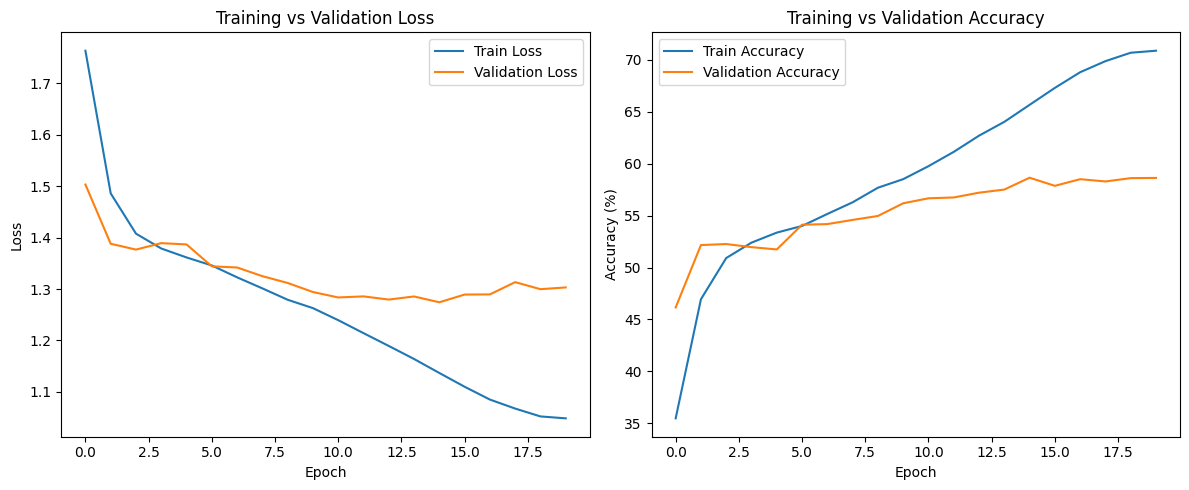

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
import torch  # <--- Add this line

# Ensure checkpoint_path and device are also defined
checkpoint_path = "/content/drive/MyDrive/kaggle/working/fairvision/checkpoint.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print("Model loaded successfully.")

Model loaded successfully.


In [41]:
test_loss, test_accuracy = evaluate(model, test_loader)

print("\nStarting final testing...")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.2f}%")


Starting final testing...
Final Test Loss: 1.2831
Final Test Accuracy: 57.35%


/tmp/ipykernel_9360/2933546730.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_sorted.values, y=race_sorted.index, ax=axes[0], palette='viridis')
/tmp/ipykernel_9360/2933546730.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_metrics.index, y=gender_metrics.values, ax=axes[1], palette='coolwarm')
/tmp/ipykernel_9360/2933546730.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sev_sorted.values, y=sev_sorted.index, ax=axes[2], palette='magma')


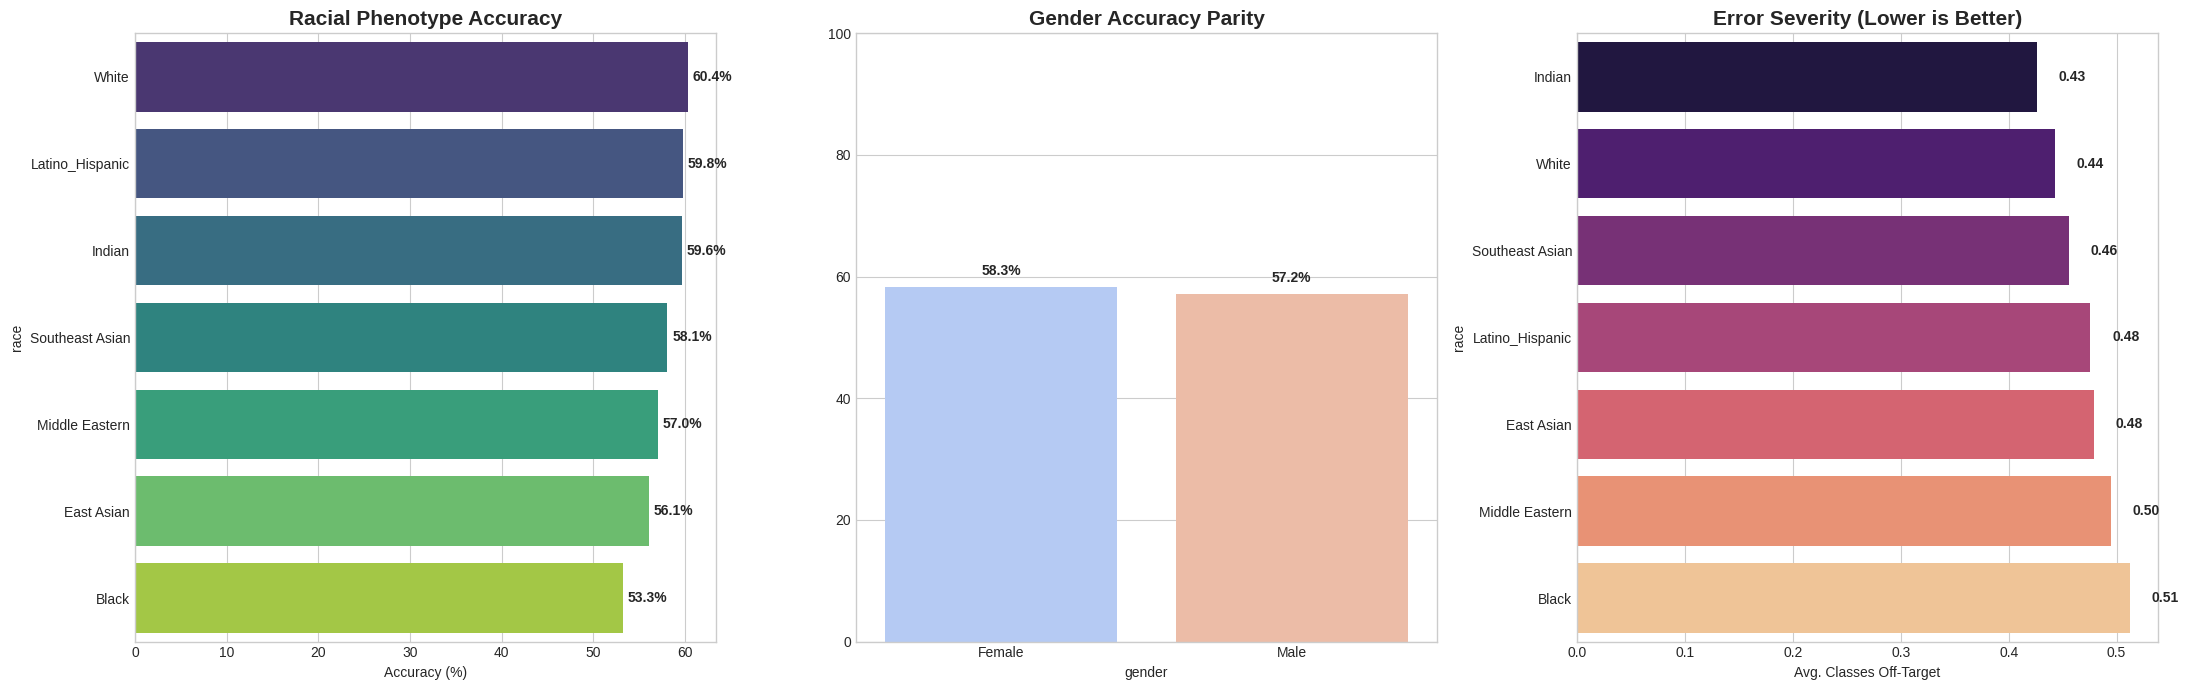

In [44]:
import seaborn as sns

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: Accuracy by Race Group
race_sorted = race_metrics.sort_values(ascending=False)
sns.barplot(x=race_sorted.values, y=race_sorted.index, ax=axes[0], palette='viridis')
axes[0].set_title('Racial Phenotype Accuracy', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Accuracy (%)')
for i, v in enumerate(race_sorted.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

# Panel 2: Gender Parity
sns.barplot(x=gender_metrics.index, y=gender_metrics.values, ax=axes[1], palette='coolwarm')
axes[1].set_title('Gender Accuracy Parity', fontsize=15, fontweight='bold')
axes[1].set_ylim(0, 100)
for i, v in enumerate(gender_metrics.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Panel 3: Error Severity (Average Class Distance)
sev_sorted = severity_metrics.sort_values()
sns.barplot(x=sev_sorted.values, y=sev_sorted.index, ax=axes[2], palette='magma')
axes[2].set_title('Error Severity (Lower is Better)', fontsize=15, fontweight='bold')
axes[2].set_xlabel('Avg. Classes Off-Target')
for i, v in enumerate(sev_sorted.values):
    axes[2].text(v + 0.02, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('FairVision_Final_Audit.png', dpi=300)
plt.show()